loading annotations into memory...
Done (t=13.14s)
creating index...
index created!
Number of images: 118287
Number of annotations: 860001
Average number of annotations per image: 7.27
Bounding box area statistics (in pixels^2):
  Minimum area: 0.0
  Maximum area: 409600.0
  Mean area: 21455.83
  Median area: 3301.01
Bounding box width statistics (in pixels):
  Minimum width: 0.23
  Maximum width: 640.0
  Mean width: 103.89
Bounding box height statistics (in pixels):
  Minimum height: 0.0
  Maximum height: 640.0
  Mean height: 107.42
Processing image: /caa/Homes01/mburges/datasets/coco/train2017/000000405842.jpg


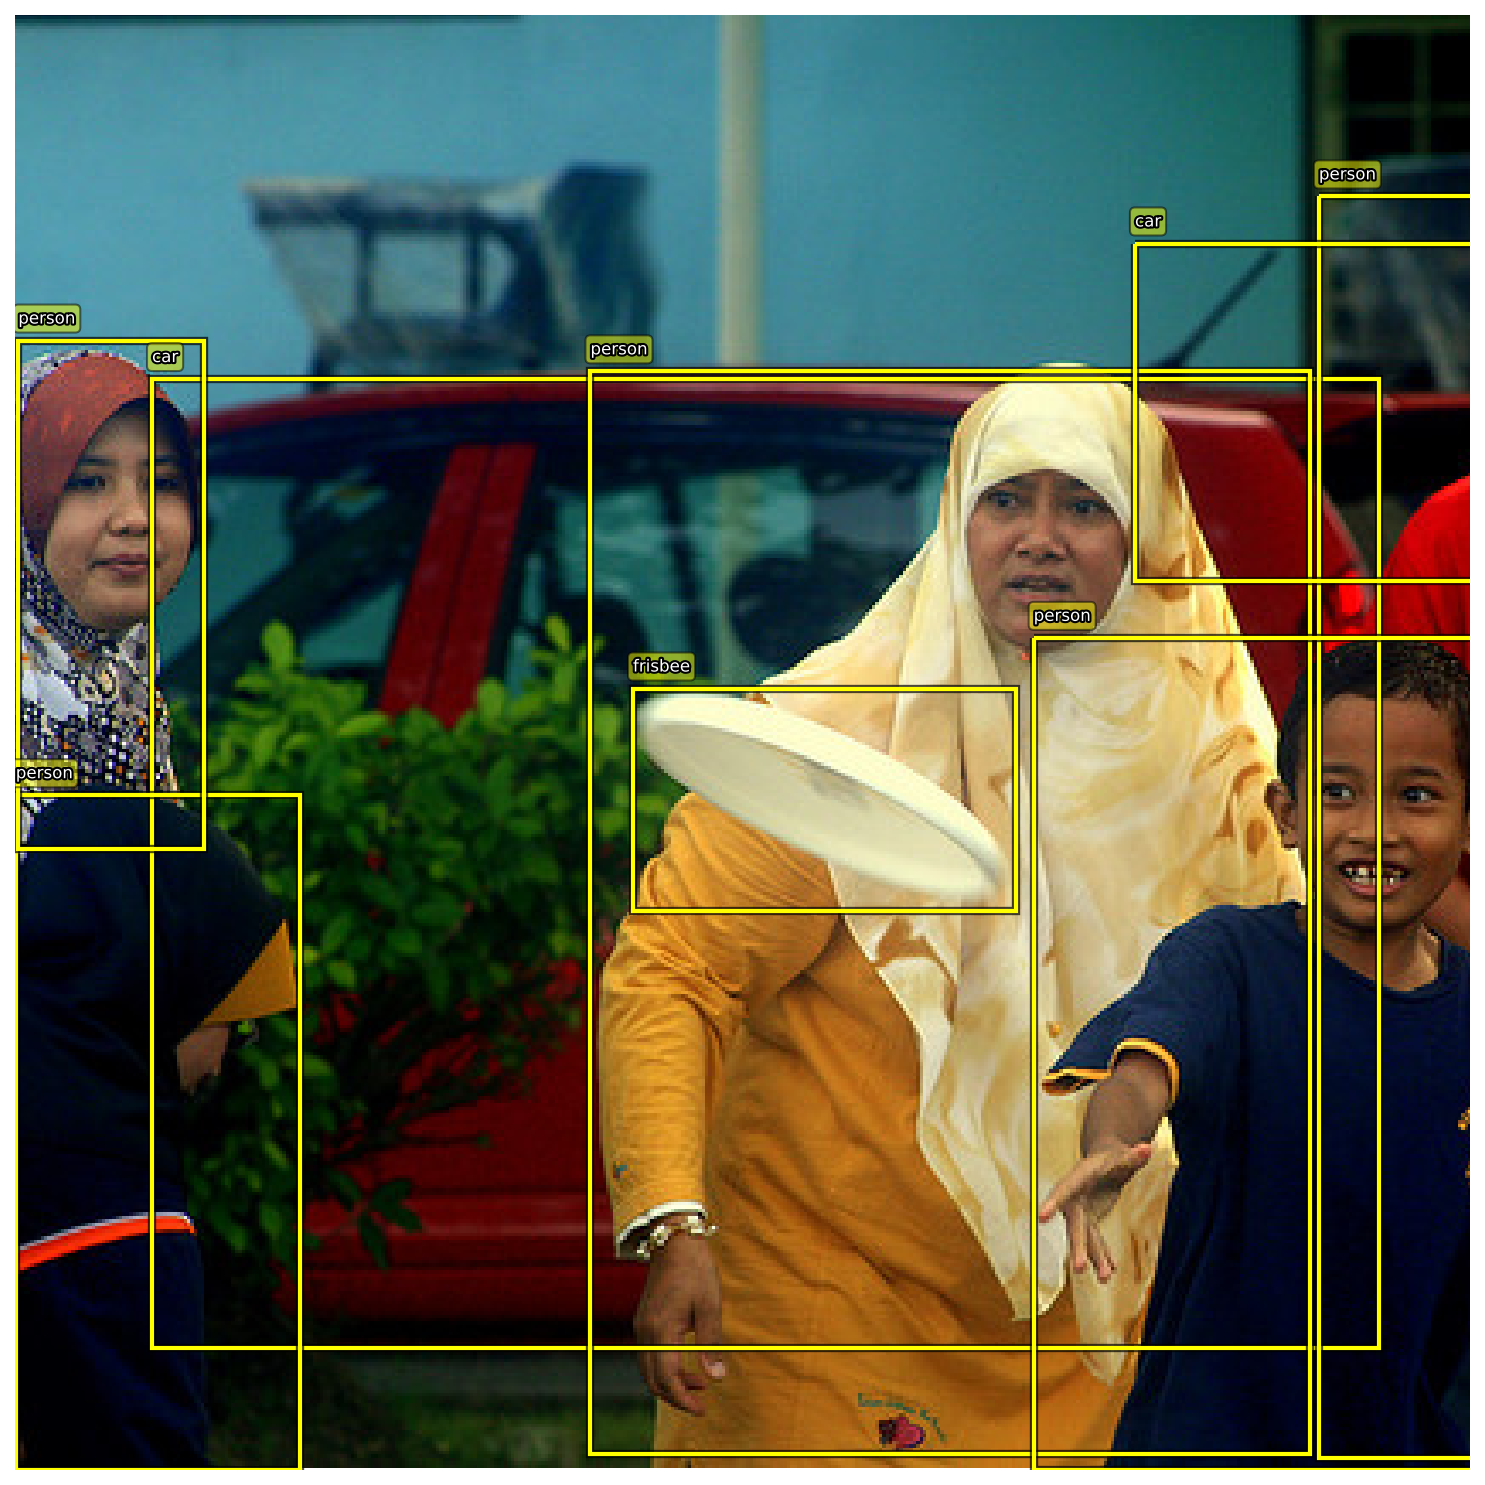

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO
import argparse
import matplotlib.patheffects as path_effects
import numpy as np

def calculate_dataset_statistics(coco):
    """
    Calculate and print statistics for the COCO dataset.
    Parameters:
    - coco: COCO object loaded from the JSON file.
    """
    # Number of images
    num_images = len(coco.getImgIds())
    print(f"Number of images: {num_images}")

    # Number of annotations
    ann_ids = coco.getAnnIds()
    num_annotations = len(ann_ids)
    print(f"Number of annotations: {num_annotations}")

    # Average number of annotations per image
    if num_images > 0:
        avg_annotations_per_image = num_annotations / num_images
        print(f"Average number of annotations per image: {avg_annotations_per_image:.2f}")
    else:
        print("No images found in the dataset.")

    # Bounding box statistics
    areas = []
    widths = []
    heights = []
    annotations = coco.loadAnns(ann_ids)
    for ann in annotations:
        bbox = ann['bbox']
        x, y, width, height = bbox
        area = width * height
        areas.append(area)
        widths.append(width)
        heights.append(height)

    if areas:
        print(f"Bounding box area statistics (in pixels^2):")
        print(f"  Minimum area: {min(areas)}")
        print(f"  Maximum area: {max(areas)}")
        print(f"  Mean area: {sum(areas) / len(areas):.2f}")
        print(f"  Median area: {np.median(areas):.2f}")
    else:
        print("No bounding box areas found.")

    if widths:
        print(f"Bounding box width statistics (in pixels):")
        print(f"  Minimum width: {min(widths)}")
        print(f"  Maximum width: {max(widths)}")
        print(f"  Mean width: {sum(widths) / len(widths):.2f}")
    else:
        print("No bounding box widths found.")

    if heights:
        print(f"Bounding box height statistics (in pixels):")
        print(f"  Minimum height: {min(heights)}")
        print(f"  Maximum height: {max(heights)}")
        print(f"  Mean height: {sum(heights) / len(heights):.2f}")
    else:
        print("No bounding box heights found.")


def plot_random_images_with_bboxes(json_path, image_folder, num_images=4, dataset_name=None):
    """
    Plot random images from a COCO dataset with bounding boxes and category labels, each in its own plot.
    Bounding boxes are yellow with a black outline, and text labels have a black outline for better visibility.

    Parameters:
    - json_path: Path to the COCO annotations JSON file.
    - image_folder: Path to the folder containing the images.
    - num_images: Number of random images to display (default: 4).
    - dataset_name: Optional name of the dataset (unused in this example).
    """
    # Load the COCO annotations
    coco = COCO(json_path)

    # Calculate and print dataset statistics
    calculate_dataset_statistics(coco)

    # Get all image IDs
    image_ids = coco.getImgIds()

    # Check if there are enough images
    if len(image_ids) < num_images:
        raise ValueError(f"There are fewer than {num_images} images in the dataset.")

    # Select random image IDs
    selected_image_ids = random.sample(image_ids, num_images)

    for img_id in selected_image_ids:
        # Create a new figure for each image
        fig, ax = plt.subplots(figsize=(10, 10), dpi=150)  # Adjust figure size as needed

        # Get image info
        img_info = coco.loadImgs(img_id)[0]
        image_path = os.path.join(image_folder, img_info['file_name'])

        print(f"Processing image: {image_path}")

        try:
            # Load the image with Pillow
            image = Image.open(image_path)
            # Convert to RGB just in case (e.g., if the image is in another mode)
            image = image.convert('RGB')
        except IOError:
            raise FileNotFoundError(f"Image not found at {image_path}")

        width, height = image.size
        ax.set_xlim(0, width)
        ax.set_ylim(height, 0)  # Invert y-axis to match image coordinates

        # Normalize the image to be displayed correctly
        img_np = np.array(image)
        img_norm = (img_np - img_np.min()) / (img_np.max() - img_np.min())

        # Display the image
        ax.imshow(img_norm)

        # Get annotations for the image
        ann_ids = coco.getAnnIds(imgIds=img_id)
        annotations = coco.loadAnns(ann_ids)

        # Draw each bounding box and label
        for ann in annotations:
            bbox = ann['bbox']
            x, y, width, height = bbox

            # Create a yellow rectangle with a black outline
            # We'll simulate the outline by drawing a thicker black rectangle underneath
            # First, draw the black outline (thicker rectangle)
            outline_rect = plt.Rectangle((x, y), width, height, fill=False,
                                         edgecolor='black', linewidth=4, alpha=0.7)
            ax.add_patch(outline_rect)
            # Then, draw the yellow rectangle (thinner rectangle on top)
            rect = plt.Rectangle((x, y), width, height, fill=False,
                                 edgecolor='yellow', linewidth=2, clip_on=True)
            ax.add_patch(rect)

            # Get category name
            category_id = ann['category_id']
            category_info = coco.loadCats(category_id)[0]
            category_name = category_info['name']

            # Add text label with black outline
            text = ax.text(x, y - 5, category_name, color='white', fontsize=8,
                           bbox=dict(facecolor='yellow', alpha=0.5, edgecolor='black', boxstyle='round'), clip_on=True)
            # Add path effect to create outline around text
            text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='black')])

        # Set extend such that the image is square by the shortest side
        h, w = image.size
        min_side = min(h, w)
        ax.set_xlim(0, min_side)
        ax.set_ylim(min_side, 0)  # Invert y-axis to match image
        ax.axis('off')
        plt.tight_layout()
        # plt.savefig(f"../plots/{dataset_name}_image_{img_id}.jpg", bbox_inches='tight', pad_inches=0.1)
        plt.show()

random.seed(44)  # For reproducibility

num_images = 1
### CHAI
# dataset_name = 'chai'
# json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/CHAI/annotations/instances_train2017.json'
# image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/CHAI/images'
### Tiny DOTA
# dataset_name = 'tiny_dota'
# json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024_tiny_abb.json'
# image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/images'
### fMoW
# dataset_name = 'fmow'
# json_path = '/caa/Homes01/mburges/datasets/fMoW/annotations/fmow_coco.json'
# image_folder = '/caa/Homes01/mburges/datasets/fMoW/images'
## FAIR1M
# dataset_name = 'fair1m'
# json_path = '/caa/Homes01/mburges/datasets/FAIR1M/coco_annotations.json'
# image_folder = '/caa/Homes01/mburges/datasets/FAIR1M/images'
### HRSC2016
# dataset_name = 'hrsc2016'
# json_path = '/caa/Homes01/mburges/datasets/hrsc2016/annotations/hrsc2016_coco.json'
# image_folder = '/caa/Homes01/mburges/datasets/hrsc2016/images'
### xView
# dataset_name = 'xview'
# json_path = '/caa/Homes01/mburges/datasets/xView/annotations/xView_coco.json'
# image_folder = '/caa/Homes01/mburges/datasets/xView/images'
### SarDet
# dataset_name = 'sardet'
# json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/SARDet-100K/annotations/train_split_corrected.json'
# image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/SARDet-100K/train'
### DOTAv2
dataset_name = 'dota_v2'
json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024.json'
image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/images'
### AI-TODa
# dataset_name = 'ai_tod'
# json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/AI-TOD/annotations/instances_train2017.json'
# image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/AI-TOD/train'
### COCO
# dataset_name = 'coco'
# json_path = '/caa/Homes01/mburges/datasets/coco/annotations/instances_train2017.json'
# image_folder = '/caa/Homes01/mburges/datasets/coco/train2017'
### DIOR
# dataset_name = 'dior'
# json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/DIOR/annotations/instances_train2017.json'
# image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/DIOR/train'

# Call the function with the provided arguments
plot_random_images_with_bboxes(json_path, image_folder, num_images, dataset_name)


In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO
from pycocotools import mask as maskUtils
import argparse
import matplotlib.patheffects as path_effects
import numpy as np


def plot_cropped_examples(json_path, image_folder, num_examples=4, dataset_name=None, padding_factor=1.5):
    """
    Plot cropped regions around random annotations from a COCO dataset.
    For each annotation, creates two plots: one with bounding box and one with segmentation mask.
    
    Parameters:
    - json_path: Path to the COCO annotations JSON file.
    - image_folder: Path to the folder containing the images.
    - num_examples: Number of random examples to display (default: 4).
    - dataset_name: Optional name of the dataset.
    - padding_factor: Factor to expand crop area around bounding box (default: 1.5).
    """
    coco = COCO(json_path)

    ann_ids = coco.getAnnIds()
    
    if len(ann_ids) < num_examples:
        raise ValueError(f"There are fewer than {num_examples} annotations in the dataset.")

    selected_ann_ids = random.sample(ann_ids, num_examples)

    for idx, ann_id in enumerate(selected_ann_ids):
        ann = coco.loadAnns(ann_id)[0]
        img_id = ann['image_id']
        
        img_info = coco.loadImgs(img_id)[0]
        image_path = os.path.join(image_folder, img_info['file_name'])

        try:
            image = Image.open(image_path)
            image = image.convert('RGB')
        except IOError:
            raise FileNotFoundError(f"Image not found at {image_path}")

        img_width, img_height = image.size
        img_np = np.array(image)

        bbox = ann['bbox']
        x, y, width, height = bbox
        
        center_x = x + width / 2
        center_y = y + height / 2
        crop_width = width * padding_factor
        crop_height = height * padding_factor
        
        crop_x1 = max(0, int(center_x - crop_width / 2))
        crop_y1 = max(0, int(center_y - crop_height / 2))
        crop_x2 = min(img_width, int(center_x + crop_width / 2))
        crop_y2 = min(img_height, int(center_y + crop_height / 2))
        
        cropped_img = img_np[crop_y1:crop_y2, crop_x1:crop_x2]
        
        bbox_crop_x = x - crop_x1
        bbox_crop_y = y - crop_y1
        
        category_id = ann['category_id']
        category_info = coco.loadCats(category_id)[0]
        category_name = category_info['name']
        
        fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
        ax.imshow(cropped_img)
        
        outline_rect = plt.Rectangle((bbox_crop_x, bbox_crop_y), width, height, 
                                    fill=False, edgecolor='black', linewidth=4, alpha=0.7)
        ax.add_patch(outline_rect)
        rect = plt.Rectangle((bbox_crop_x, bbox_crop_y), width, height, 
                            fill=False, edgecolor='yellow', linewidth=2)
        ax.add_patch(rect)
        
        # text = ax.text(bbox_crop_x, bbox_crop_y - 5, category_name, 
        #               color='white', fontsize=10,
        #               bbox=dict(facecolor='yellow', alpha=0.5, edgecolor='black', boxstyle='round'))
        # text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='black')])
        
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(f"../plots/{dataset_name}_crop_{idx}_bbox.png", bbox_inches='tight', pad_inches=0.1)
        plt.show()
        
        if 'segmentation' in ann and ann['segmentation']:
            fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
            ax.imshow(cropped_img)
            
            seg = ann['segmentation']

            print(seg)
            
            if isinstance(seg, list):
                for polygon in seg:
                    poly_array = np.array(polygon).reshape(-1, 2)
                    poly_array[:, 0] -= crop_x1
                    poly_array[:, 1] -= crop_y1
                    from matplotlib.patches import Polygon
                    poly_patch = Polygon(poly_array, fill=True, facecolor='yellow', 
                                       edgecolor='yellow', alpha=0.5, linewidth=2)
                    ax.add_patch(poly_patch)
            elif isinstance(seg, dict):
                if 'counts' in seg and 'size' in seg:
                    mask = maskUtils.decode(seg)
                    mask_crop = mask[crop_y1:crop_y2, crop_x1:crop_x2]
                    ax.imshow(mask_crop, alpha=0.5, cmap='YlOrRd')
            
            # text = ax.text(bbox_crop_x, bbox_crop_y - 5, category_name, 
            #               color='white', fontsize=10,
            #               bbox=dict(facecolor='yellow', alpha=0.5, edgecolor='black', boxstyle='round'))
            # text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='black')])
            
            ax.axis('off')
            plt.tight_layout()
            plt.savefig(f"../plots/{dataset_name}_crop_{idx}_seg.png", bbox_inches='tight', pad_inches=0.1)
            plt.show()
        else:
            print(f"No segmentation data available for annotation {ann_id}")


random.seed(44)

num_examples = 16

### CHAI
# dataset_name = 'chai'
# json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/CHAI/annotations/instances_train2017.json'
# image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/CHAI/images'
### Tiny DOTA
dataset_name = 'tiny_dota'
json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024_tiny_abb.json'
image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/images'
### fMoW
# dataset_name = 'fmow'
# json_path = '/caa/Homes01/mburges/datasets/fMoW/annotations/fmow_coco.json'
# image_folder = '/caa/Homes01/mburges/datasets/fMoW/images'
## FAIR1M
# dataset_name = 'fair1m'
# json_path = '/caa/Homes01/mburges/datasets/FAIR1M/coco_annotations.json'
# image_folder = '/caa/Homes01/mburges/datasets/FAIR1M/images'
### HRSC2016
# dataset_name = 'hrsc2016'
# json_path = '/caa/Homes01/mburges/datasets/hrsc2016/annotations/hrsc2016_coco.json'
# image_folder = '/caa/Homes01/mburges/datasets/hrsc2016/images'
### xView
# dataset_name = 'xview'
# json_path = '/caa/Homes01/mburges/datasets/xView/annotations/xView_coco.json'
# image_folder = '/caa/Homes01/mburges/datasets/xView/images'
### SarDet
# dataset_name = 'sardet'
# json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/SARDet-100K/annotations/train_split_corrected.json'
# image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/SARDet-100K/train'
### DOTAv2
# dataset_name = 'dota_v2'
# json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024.json'
# image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/images'
### AI-TOD
# dataset_name = 'ai_tod'
# json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/AI-TOD/annotations/instances_train2017.json'
# image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/AI-TOD/train'
### COCO
# dataset_name = 'coco'
# json_path = '/caa/Homes01/mburges/datasets/coco/annotations/instances_train2017.json'
# image_folder = '/caa/Homes01/mburges/datasets/coco/train2017'
### DIOR
# dataset_name = 'dior'
# json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/DIOR/annotations/instances_train2017.json'
# image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/DIOR/train'

plot_cropped_examples(json_path, image_folder, num_examples, dataset_name)